In [ ]:
import subprocess, sys

subprocess.run([sys.executable, '-m', 'venv', r'C:\Users\bacus\tf_env'], capture_output=False)

pip = r'C:\Users\bacus\tf_env\Scripts\pip.exe'
subprocess.run([pip, 'install', 'tensorflow==2.17.0'], capture_output=False)
subprocess.run([pip, 'install', 'opencv-python', 'albumentations',
                'scikit-learn', 'matplotlib', 'seaborn', 
                'ipykernel'], capture_output=False)

print("Done!")

Done!


In [14]:
import subprocess
python = r'C:\Users\bacus\tf_env\Scripts\python.exe'
subprocess.run([python, '-m', 'ipykernel', 'install', 
                '--user', '--name=tf_env', '--display-name=Python (tf_env)'], 
               capture_output=False)
print("Kernel registered!")

Kernel registered!


In [15]:
import tensorflow as tf
print("TF version:", tf.__version__)

TF version: 2.18.0


In [16]:
from pathlib import Path
import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
import albumentations as A
from albumentations.core.composition import Compose
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("TF version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPUs:", gpus)

TF version: 2.18.0
Keras version: 3.14.0
GPUs: []


In [17]:
DATASET_ROOT_PATH = r'C:\Users\bacus\Documents\Cariex Dataset'
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 30
MODEL_NAME = 'cariex_classifier'

CARIES_CLASSES = ['healthy', 'incipient_caries', 'moderate_caries', 'deep_caries']
NUM_CLASSES = len(CARIES_CLASSES)

print(f"Classes: {CARIES_CLASSES}")
print(f"Num classes: {NUM_CLASSES}")

Classes: ['healthy', 'incipient_caries', 'moderate_caries', 'deep_caries']
Num classes: 4


In [18]:
train_transforms = Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

val_transforms = Compose([])

In [ ]:
def scan_dataset(root):
    root = Path(root)
    paths, labels = [], []

    for caries_idx, caries_name in enumerate(CARIES_CLASSES):
        folder = root / caries_name
        if not folder.exists():
            print(f"Warning: not found — {folder}")
            continue
        for img_path in folder.iterdir():
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                paths.append(str(img_path))
                labels.append(caries_idx)

    print(f"\nTotal images: {len(paths)}")
    for i, name in enumerate(CARIES_CLASSES):
        print(f"  Class {i} ({name}): {labels.count(i)} images")
    return paths, labels

all_paths, all_labels = scan_dataset(DATASET_ROOT_PATH  )


Total images: 741
  Class 0 (healthy): 431 images
  Class 1 (incipient_caries): 59 images
  Class 2 (moderate_caries): 57 images
  Class 3 (deep_caries): 194 images


In [20]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)
print(f"Train: {len(train_paths)}  |  Val: {len(val_paths)}")

Train: 592  |  Val: 149


In [21]:
def load_image(img_path, img_size, transforms=None):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Failed to load: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    if transforms:
        img = transforms(image=img)['image']
    img = img.astype(np.float32) / 255.0
    return img

def create_dataset(paths, labels, img_size, batch_size, transforms=None):
    images, valid_labels = [], []

    for p, l in zip(paths, labels):
        try:
            img = load_image(p, img_size, transforms)
            images.append(img)
            valid_labels.append(l)
        except Exception as e:
            print(f"Skipping {p}: {e}")

    images    = np.array(images, dtype=np.float32)
    labels_oh = keras.utils.to_categorical(valid_labels, num_classes=NUM_CLASSES)

    print(f"Loaded {len(images)} images | shape: {images.shape}")

    ds = tf.data.Dataset.from_tensor_slices((images, labels_oh))
    ds = ds.shuffle(min(1000, len(images))).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, len(images)

print("Loading train...")
train_dataset, train_count = create_dataset(train_paths, train_labels, IMG_SIZE, BATCH_SIZE, train_transforms)
print("Loading val...")
val_dataset, val_count     = create_dataset(val_paths, val_labels, IMG_SIZE, BATCH_SIZE, val_transforms)
print(f"\nTrain: {train_count}  |  Val: {val_count}")

Loading train...
Loaded 592 images | shape: (592, 256, 256, 3)
Loading val...
Loaded 149 images | shape: (149, 256, 256, 3)

Train: 592  |  Val: 149


In [ ]:
def build_classifier(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    base_model = keras.applications.EfficientNetB3(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )
    base_model.trainable = False

    x = base_model.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(base_model.input, outputs, name='CariexClassifier')

    return model, base_model  

model, base_model = build_classifier()
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 33s 1us/step


Model: "CariexClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        960 │ block1a_se_excit

 Total params: 11,216,563 (42.79 MB)

 Trainable params: 429,956 (1.64 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

output_dir = Path(f'trained_models/{MODEL_NAME}')
output_dir.mkdir(parents=True, exist_ok=True)

# ── PHASE 1 — frozen base, train head only ──
print("\n--- Phase 1: Training head only ---")
callbacks_p1 = [
    ModelCheckpoint(str(output_dir / 'best_model.keras'),
                    monitor='val_accuracy', mode='max',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5,
                  mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=3, mode='max', min_lr=1e-7, verbose=1),
    CSVLogger(str(output_dir / 'phase1_log.csv')),
]

history1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict,
    verbose=1
)

# PHASE 2 unfreeze top layers, fine-tune ──
print("\n--- Phase 2: Fine-tuning top layers ---")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_p2 = [
    ModelCheckpoint(str(output_dir / 'best_model.keras'),
                    monitor='val_accuracy', mode='max',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10,
                  mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=5, mode='max', min_lr=1e-8, verbose=1),
    CSVLogger(str(output_dir / 'phase2_log.csv')),
]

history2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: 0.43023255813953487, 1: 3.148936170212766, 2: 3.217391304347826, 3: 0.9548387096774194}

--- Phase 1: Training head only ---
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.2407 - auc: 0.5013 - loss: 1.5217
Epoch 1: val_accuracy improved from None to 0.08054, saving model to trained_models\cariex_classifier\best_model.keras

Epoch 1: finished saving model to trained_models\cariex_classifier\best_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 47s 422ms/step - accuracy: 0.2399 - auc: 0.4939 - loss: 1.6206 - val_accuracy: 0.0805 - val_auc: 0.4522 - val_loss: 1.4109 - learning_rate: 1.0000e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.1840 - auc: 0.4553 - loss: 1.4699
Epoch 2: val_accuracy improved from 0.08054 to 0.30201, saving model to trained_models\cariex_classifier\best_model.keras

Epoch 2: finished saving model to trained_models\cariex_classifier\best_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 26s 353ms/step - accuracy: 0.2078 - auc:

In [25]:
best_model = keras.models.load_model(str(output_dir / 'best_model.keras'))
results = best_model.evaluate(val_dataset, verbose=1)
print(f"Loss: {results[0]:.4f} | Accuracy: {results[1]:.4f} | AUC: {results[2]:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - accuracy: 0.5705 - auc: 0.7784 - loss: 1.1959
Loss: 1.1959 | Accuracy: 0.5705 | AUC: 0.7784


In [26]:
best_model = keras.models.load_model(str(output_dir / 'best_model.keras'))
results = best_model.evaluate(val_dataset, verbose=1)
print(f"Loss: {results[0]:.4f} | Accuracy: {results[1]:.4f} | AUC: {results[2]:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.5705 - auc: 0.7784 - loss: 1.1959
Loss: 1.1959 | Accuracy: 0.5705 | AUC: 0.7784


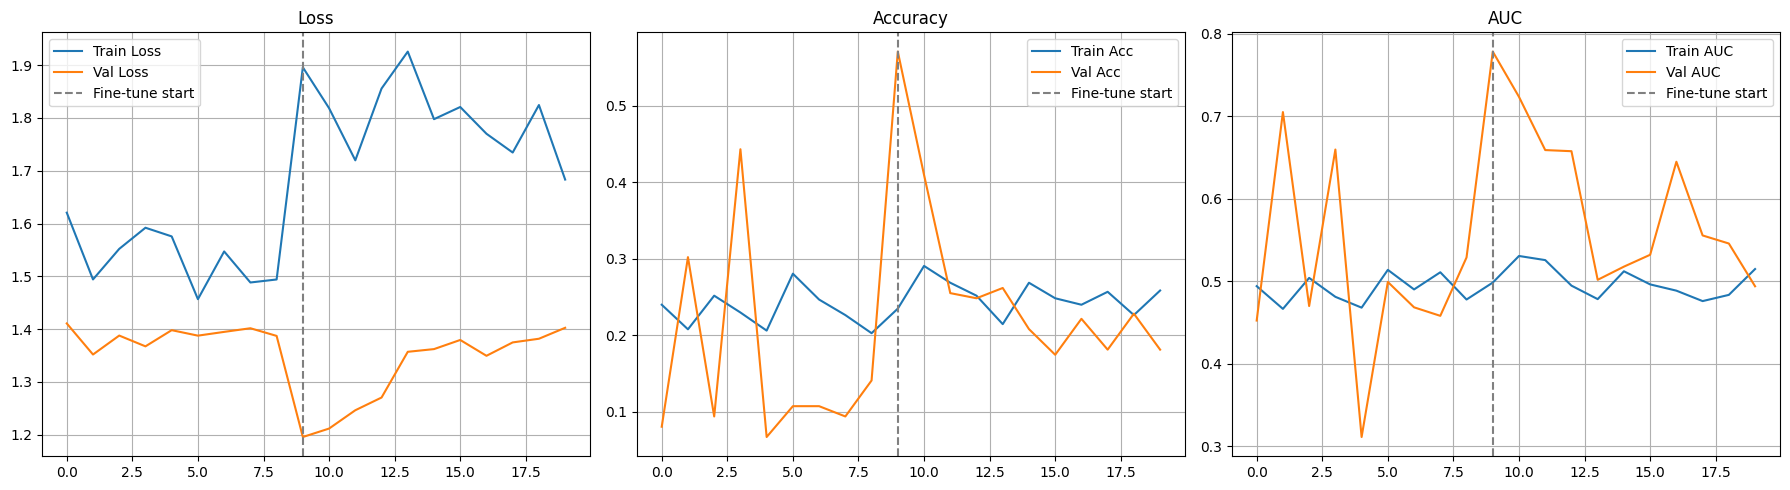

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def combine(h1, h2, key):
    return h1.history[key] + h2.history[key]

axes[0].plot(combine(history1, history2, 'loss'),     label='Train Loss')
axes[0].plot(combine(history1, history2, 'val_loss'), label='Val Loss')
axes[0].axvline(len(history1.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(combine(history1, history2, 'accuracy'),     label='Train Acc')
axes[1].plot(combine(history1, history2, 'val_accuracy'), label='Val Acc')
axes[1].axvline(len(history1.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(combine(history1, history2, 'auc'),     label='Train AUC')
axes[2].plot(combine(history1, history2, 'val_auc'), label='Val AUC')
axes[2].axvline(len(history1.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
axes[2].set_title('AUC'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

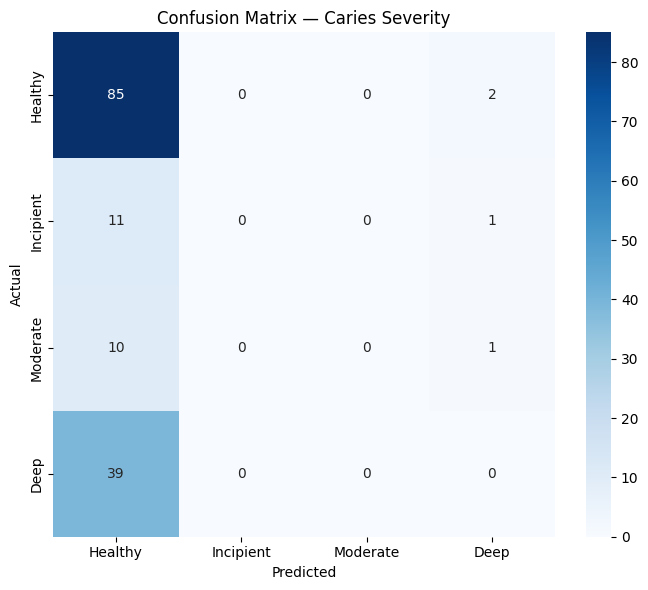

              precision    recall  f1-score   support

     Healthy       0.59      0.98      0.73        87
   Incipient       0.00      0.00      0.00        12
    Moderate       0.00      0.00      0.00        11
        Deep       0.00      0.00      0.00        39

    accuracy                           0.57       149
   macro avg       0.15      0.24      0.18       149
weighted avg       0.34      0.57      0.43       149



c:\Users\bacus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bacus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bacus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for imgs, lbls in val_dataset:
    preds = best_model.predict(imgs, verbose=0)
    y_true.extend(np.argmax(lbls.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Incipient', 'Moderate', 'Deep'],
            yticklabels=['Healthy', 'Incipient', 'Moderate', 'Deep'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Caries Severity')
plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred,
      target_names=['Healthy', 'Incipient', 'Moderate', 'Deep']))

# Segmentation Model (U-Net)

In [ ]:
def build_unet(input_shape=(256, 256, 3)):
    """Build U-Net model for semantic segmentation."""
    inputs = keras.Input(shape=input_shape)
    
    # Encoder
    c1 = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = keras.layers.MaxPooling2D((2, 2))(c1)
    
    c2 = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = keras.layers.MaxPooling2D((2, 2))(c2)
    
    c3 = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    p3 = keras.layers.MaxPooling2D((2, 2))(c3)
    
    c4 = keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    c4 = keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c4)
    
    # Decoder
    u5 = keras.layers.UpSampling2D((2, 2))(c4)
    u5 = keras.layers.concatenate([u5, c3])
    c5 = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u5)
    c5 = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c5)
    
    u6 = keras.layers.UpSampling2D((2, 2))(c5)
    u6 = keras.layers.concatenate([u6, c2])
    c6 = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u6)
    c6 = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c6)
    
    u7 = keras.layers.UpSampling2D((2, 2))(c6)
    u7 = keras.layers.concatenate([u7, c1])
    c7 = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u7)
    c7 = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c7)
    
    # Output layer (binary segmentation)
    outputs = keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)
    
    model = keras.Model(inputs, outputs, name='UNet')
    return model

unet_model = build_unet()
unet_model.summary()


In [ ]:
unet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Dice(name='dice')]
)


In [ ]:
s# Create synthetic segmentation masks for demonstration
# (In practice, you'd load actual annotated masks)

def create_synthetic_masks(images, labels):
    """Generate synthetic segmentation masks based on class labels."""
    masks = np.zeros((images.shape[0], images.shape[1], images.shape[2], 1), dtype=np.float32)
    
    for i in range(len(images)):
        # Synthetic approach: use label as indicator for caries presence
        if labels[i] > 0:  # If not healthy
            # Create a random circular region representing caries
            center = (np.random.randint(50, 206), np.random.randint(50, 206))
            radius = 20 + labels[i] * 10  # Larger for deeper caries
            y, x = np.ogrid[:IMG_SIZE, :IMG_SIZE]
            mask_region = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= radius ** 2
            masks[i, mask_region, 0] = 1.0
    
    return masks

# Prepare training data
train_images, train_labels_array = [], []
for paths, labels in zip([train_paths], [train_labels]):
    for p, l in zip(paths, labels):
        try:
            img = load_image(p, IMG_SIZE, train_transforms)
            train_images.append(img)
            train_labels_array.append(l)
        except:
            pass

train_images = np.array(train_images, dtype=np.float32)
train_labels_array = np.array(train_labels_array)
train_masks = create_synthetic_masks(train_images, train_labels_array)

print(f"Train images: {train_images.shape} | Masks: {train_masks.shape}")

# Create TF dataset for segmentation
seg_train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
seg_train_ds = seg_train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
unet_output_dir = Path(f'trained_models/unet_segmentation')
unet_output_dir.mkdir(parents=True, exist_ok=True)

unet_callbacks = [
    ModelCheckpoint(str(unet_output_dir / 'best_unet.keras'),
                    monitor='loss', mode='min',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='loss', patience=5,
                  mode='min', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='loss', factor=0.5,
                      patience=3, mode='min', min_lr=1e-7, verbose=1),
    CSVLogger(str(unet_output_dir / 'segmentation_log.csv')),
]

print("Training U-Net for segmentation...")
unet_history = unet_model.fit(
    seg_train_ds,
    epochs=15,
    callbacks=unet_callbacks,
    verbose=1
)

print("U-Net training complete!")


In [ ]:
# Visualize U-Net segmentation predictions
best_unet = keras.models.load_model(str(unet_output_dir / 'best_unet.keras'))

# Get predictions on sample images
sample_indices = np.random.choice(len(train_images), 5, replace=False)
sample_images = train_images[sample_indices]
sample_masks = train_masks[sample_indices]
predictions = best_unet.predict(sample_images, verbose=0)

fig, axes = plt.subplots(5, 3, figsize=(12, 15))

for i, idx in enumerate(sample_indices):
    # Original image
    axes[i, 0].imshow(sample_images[i])
    axes[i, 0].set_title(f'Original Image {i+1}')
    axes[i, 0].axis('off')
    
    # Ground truth mask
    axes[i, 1].imshow(sample_masks[i].squeeze(), cmap='gray')
    axes[i, 1].set_title(f'Ground Truth Mask {i+1}')
    axes[i, 1].axis('off')
    
    # Predicted mask
    axes[i, 2].imshow(predictions[i].squeeze(), cmap='gray')
    axes[i, 2].set_title(f'Predicted Mask {i+1}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
